# Instrução do Projeto

A Film Junky Union, uma nova comunidade para entusiastas de filmes clássicos, está desenvolvendo um sistema para filtrar e categorizar resenhas de filmes. O objetivo é treinar um modelo para detectar automaticamente resenhas negativas. Você usará um conjunto de dados de resenhas de filmes do IMDB com rotulagem de polaridade para criar um modelo para classificar resenhas como positivas e negativas. Ele precisará ter um valor F1 de pelo menos 0,85.

## Inicialização

In [33]:
# importação das bibliotecas

import math

import numpy as np
import pandas as pd
import re

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

import sklearn.metrics as metrics
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import nltk
from nltk.corpus import stopwords

In [34]:
# verificação dos estilos disponíveis 
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [35]:
# renderizar os gráficos diretamente abaixo do código
%matplotlib inline
%config InlineBackend.figure_format = 'png'     # define o formato de saída de imagens como PNG
%config InlineBackend.figure_format = 'retina'  # define os gráficos de melhor qualidade em telas HiDPI

plt.style.use('seaborn-v0_8-darkgrid')          # define estética visual dos gráficos

In [36]:
# isso é para usar progress_apply, leia mais em https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()   # comando "ensina" pandas a conversar com a biblioteca tqdm

## Carregar Dados

In [37]:
# carregar dados

try:
    df_reviews = pd.read_csv('imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})
    print(f"✅ Arquivo carregado com sucesso!")
    print('=' * 60)
    print(f"🔍  Visualização das Primeiras Linhas do Dataframe")
    print('=' * 60)
    display(df_reviews.head())
    print('=' * 60)
    print(f"📐 Dimensões do DataFrame")
    print('=' * 60)
    print(f"Número de Linhas: {df_reviews.shape[0]}")
    print(f"Número de Colunas: {df_reviews.shape[1]}")
except Exception as e:
    print(f"❌ Erro na leitura do arquivo. Detalhes: {e}")

✅ Arquivo carregado com sucesso!
🔍  Visualização das Primeiras Linhas do Dataframe


,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


📐 Dimensões do DataFrame
Número de Linhas: 47331
Número de Colunas: 17


In [38]:
print('=' * 60)
print(f"ℹ️ Informações Gerais do Dataframe")
print('=' * 60)
print(df_reviews.info())

ℹ️ Informações Gerais do Dataframe
<class 'pandas.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  str    
 1   title_type       47331 non-null  str    
 2   primary_title    47331 non-null  str    
 3   original_title   47331 non-null  str    
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  str    
 6   runtime_minutes  47331 non-null  str    
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  str    
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  str    
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  str    
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  str    
 16  idx              47331 non-null  i

In [39]:
print('=' * 60)
print(f"📊 Estatísticas Descritivas do DataFrame")
print('=' * 60)
print(df_reviews.describe())

📊 Estatísticas Descritivas do DataFrame
         start_year      is_adult  average_rating         votes        rating  \
count  47331.000000  47331.000000    47329.000000       47329.0  47331.000000   
mean    1989.631235      0.001732        5.998278  25562.917323      5.484608   
std       19.600364      0.041587        1.494289  83670.039163      3.473109   
min     1894.000000      0.000000        1.400000           9.0      1.000000   
25%     1982.000000      0.000000        5.100000         827.0      2.000000   
50%     1998.000000      0.000000        6.300000        3197.0      4.000000   
75%     2004.000000      0.000000        7.100000       13974.0      9.000000   
max     2010.000000      1.000000        9.700000     1739448.0     10.000000   

                pos           idx  
count  47331.000000  47331.000000  
mean       0.498954   6279.697999  
std        0.500004   3605.702545  
min        0.000000      0.000000  
25%        0.000000   3162.000000  
50%        0.0

In [40]:
# exclusão de valores ausentes nas colunas 'votes' e 'average_rating'
print(f"Dimensões antes: {len(df_reviews)}")
null_counts = df_reviews[['votes', 'average_rating']].isna().sum()
percent_null = (null_counts / len(df_reviews)) * 100
print(f"Quantidade de valores nulos: {null_counts.values[0]}")
print(f"Representatividade de valores nulos antes do dropna(): {percent_null.values[0]:.3f}%")
df_reviews = df_reviews.dropna(subset=['votes', 'average_rating'])
print('-' * 65)
print(f"Dimensões depois: {len(df_reviews)}")
print(f"O dataset possui {df_reviews.isna().sum().sum()} valores ausentes após dropna()")

Dimensões antes: 47331
Quantidade de valores nulos: 2
Representatividade de valores nulos antes do dropna(): 0.004%
-----------------------------------------------------------------
Dimensões depois: 47329
O dataset possui 0 valores ausentes após dropna()


In [41]:
# loop para verificar valores únicos em cada coluna

cols_to_check = ['title_type', 'start_year', 'runtime_minutes', 'is_adult', 'genres', 'votes', 'rating', 'sp', 'pos', 'ds_part']

for col in cols_to_check:
    print(f"--- Coluna {col}: ---")
    print(f"Quantidade de valores únicos: {df_reviews[col].nunique()}")
    print(f"Top 10 valores mais frequentes:")
    print(df_reviews[col].value_counts().head(10))
    print("\n" + "=" * 60 + "\n")

--- Coluna title_type: ---
Quantidade de valores únicos: 10
Top 10 valores mais frequentes:
title_type
movie           36859
tvMovie          2892
video            2742
tvSeries         2246
short             887
tvMiniSeries      713
tvEpisode         635
tvSpecial         183
videoGame         154
tvShort            18
Name: count, dtype: int64


--- Coluna start_year: ---
Quantidade de valores únicos: 107
Top 10 valores mais frequentes:
start_year
2006    3275
2005    3076
2003    2355
2004    2228
2000    2108
2007    2106
2002    2071
2001    1912
1999    1813
1998    1377
Name: count, dtype: int64


--- Coluna runtime_minutes: ---
Quantidade de valores únicos: 249
Top 10 valores mais frequentes:
runtime_minutes
90     2442
95     1820
100    1420
92     1418
93     1311
96     1261
91     1226
85     1189
88     1179
94     1115
Name: count, dtype: int64


--- Coluna is_adult: ---
Quantidade de valores únicos: 2
Top 10 valores mais frequentes:
is_adult
0    47247
1       82
Name:

In [42]:
# verificação se as colunas 'sp' e 'pos' são idênticas
df_reviews['sp_binary'] = df_reviews['sp'].map({'neg': 0, 'pos': 1})
# conferência se 'sp' mapeado é igual a 'pos'
check = ((df_reviews['sp_binary']) == df_reviews['pos']).all()
print(f"As colunas sp e pos são idênticas? {check}")

As colunas sp e pos são idênticas? True


### Conclusões Iniciais

`Limpeza e Padronização dos Dados:`'
- **Dados Analisados e Considerados Adequados:** nomenclatura das colunas.
- **Valores Ausentes:** valores ausentes em quantidade não significativa foram excluídos do dataset (0.004%)
- **Balanceamento de Classes ('pos' = Target):** a média 0.49 (~ 50%) na estatística descritiva sugere balanceamento entre as classes positiva vs negativa. Pravável que não haja necessidade de aplicar técnicas de balancemento.
- **Período**: os filmes avaliados estão datados entre 1894 e 2010, implicam em vocabulários específicos usados para cada época.

`Distribuição dos Dados`:
- **title_type**: categoria dominada pelo tipo 'movie'.
- **star_year**: os anos com maior quantidade de registros está entre 1998 e 2006.
- **runtima_minutes**: maior quantidade de registros de filmes entre 85 e 100 minutos.
- **is_adult**: expressiva quantidade de filmes não adultos (47.247 vs 82), coluna quase não tem variância e deve ser descartada para treinamento do modelo.
- **genres**: os gêneros podem ser combinados, dentro so top 10, 'Drama' é a categoria que mais aparece.
- **rating**: as classigicações 5 e 6 não aparecem no dataset. Os clientes tendem a classificações extremas, 1 e 10 são as pontuações mais frequentes.
- **sp e pos**: colunas com informações idênticas. A coluna 'sp' não deverá ser usada no treinamento do modelo. Observado balanceamento ideal da target (23.715 vs 23.614).
- **ds_part**: resultado balanceado de treinamento e teste (23.796 vs 23.533)

## AED

Vamos verificar o número de filmes e resenhas ao longo dos anos.

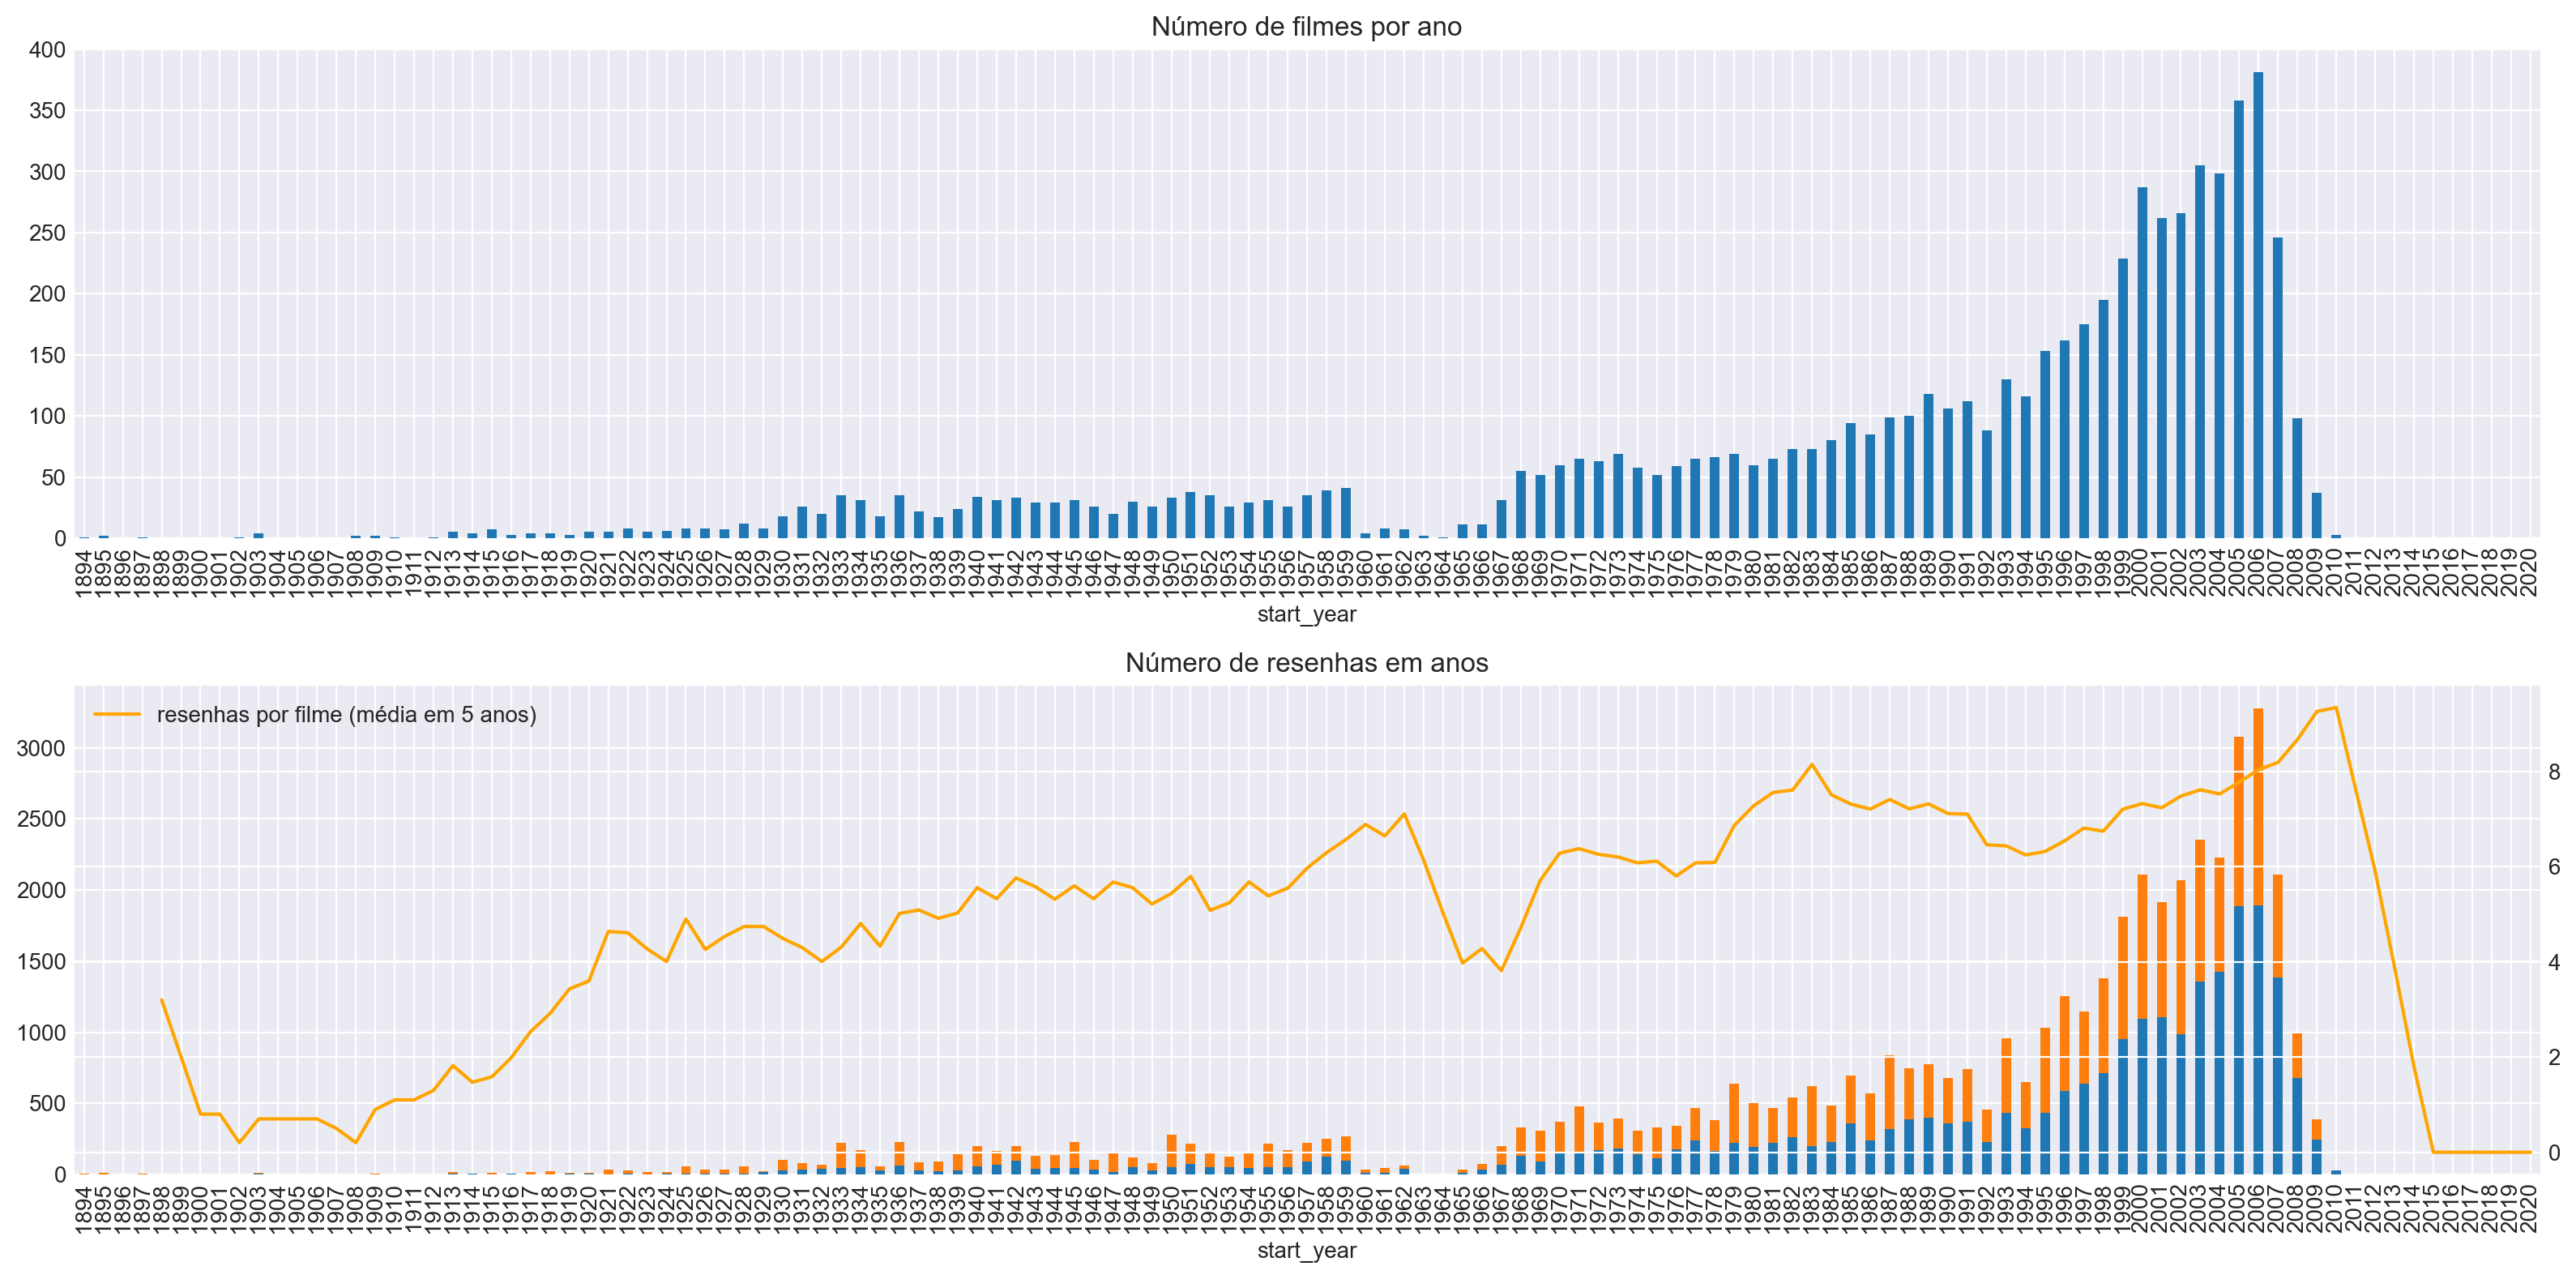

In [43]:
# análise temporal: número de filmes e resenhas por ano
# configuração dos gráficos
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

# contagem de filmes por ano, preenchendo anos sem filmes com valor zero e ordenando por ano
dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes por ano')

ax = axs[1]

# agrupamento por ano e sentimento ('pos'), conta e usa .unstack() para transformar os sentimentos em colunas
dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)
dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

# divisão do total de resenhas pelo total de filmes por ano, preenchendo anos sem filmes com valor zero e ordenando por ano
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
# aplicação de média móvel em 5 anos
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='resenhas por filme (média em 5 anos)', ax=axt)
# ajustes finais de legenda e layout
lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')
ax.set_title('Número de resenhas em anos')

fig.tight_layout()

Vamos verificar a distribuição do número de resenhas por filme com a contagem exata e o EDK (Estimativa de densidade kernel - só para saber como pode diferir da contagem exata)

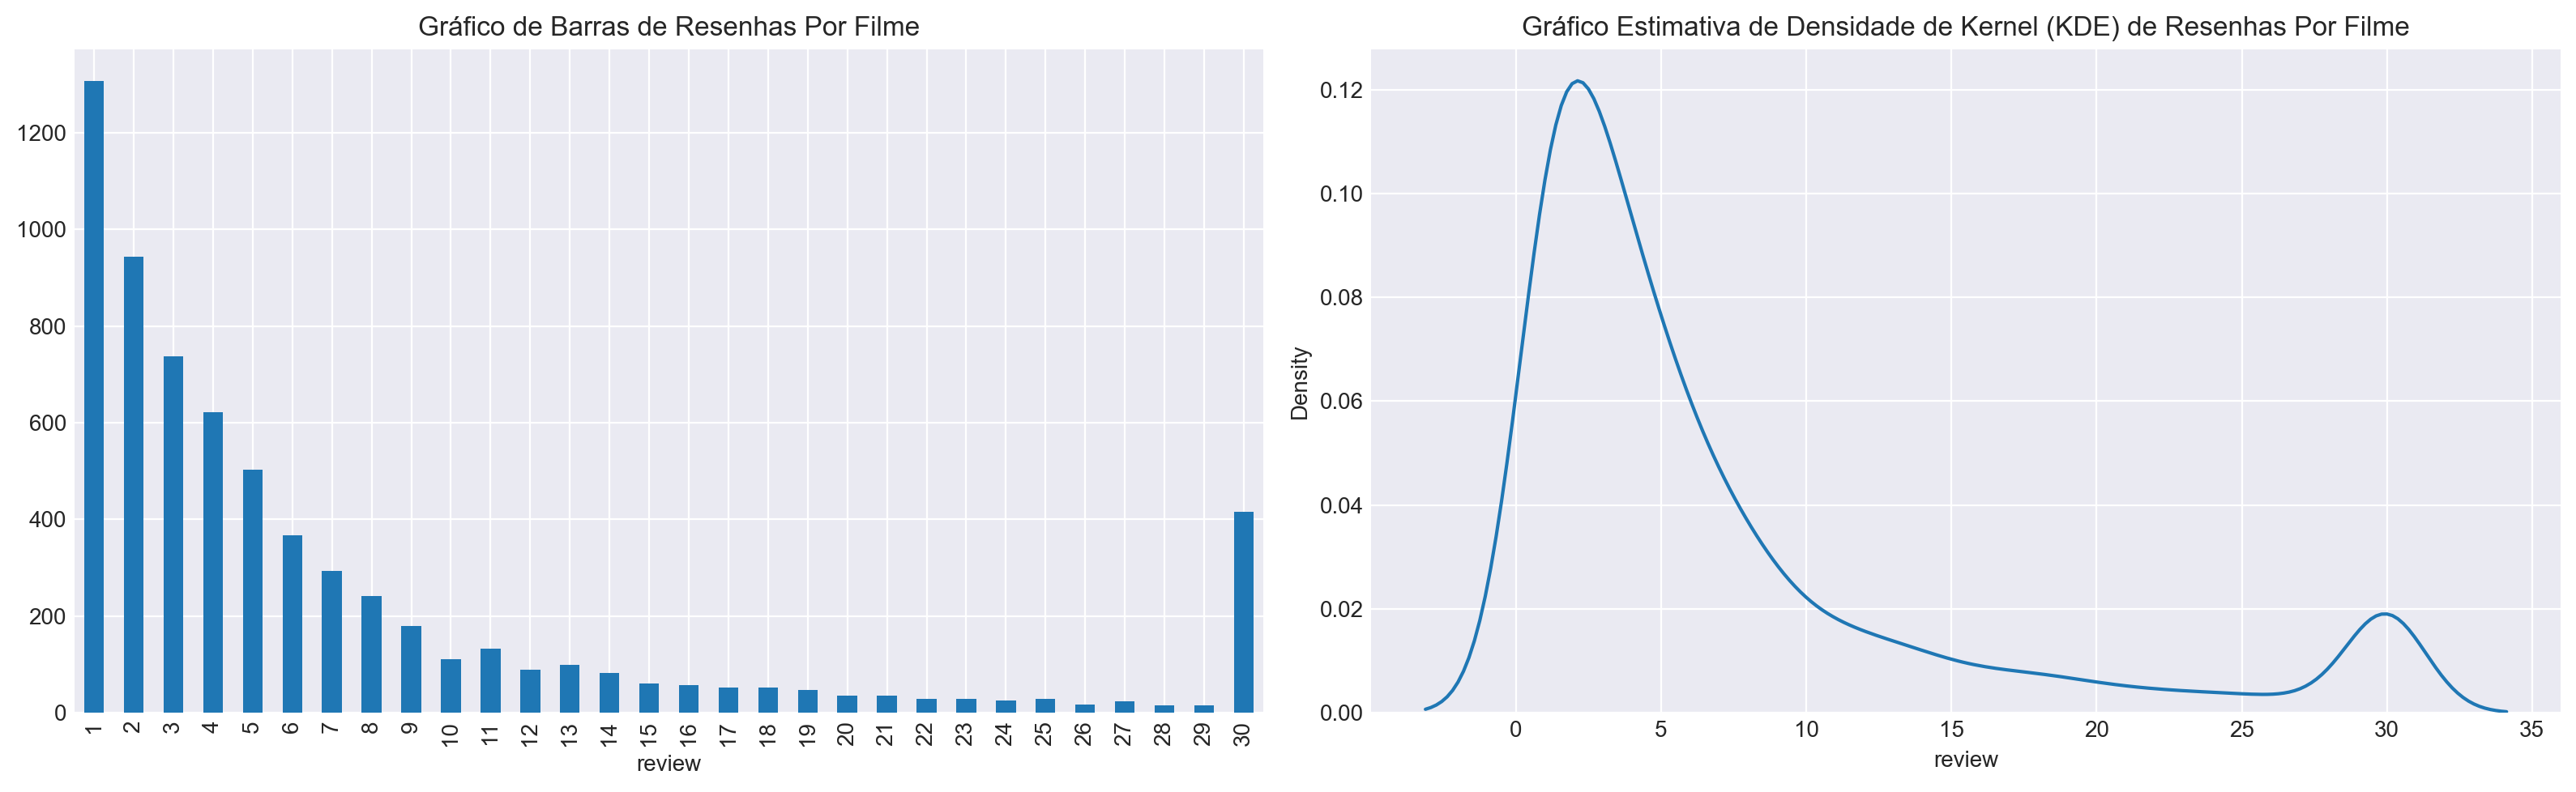

In [44]:
# análise de distribuição: quantidade de resenhas por filme
# configuração dos gráficos
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]

# agrupamento de resenhas por filme, contagem do quantitativo de resenhas por filme, ordenando por quantidade de resenhas
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de Barras de Resenhas Por Filme')

ax = axs[1]

# agrupamento de resenhas por filme, contagem do quantitativo de resenhas por filme
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico Estimativa de Densidade de Kernel (KDE) de Resenhas Por Filme')

fig.tight_layout()

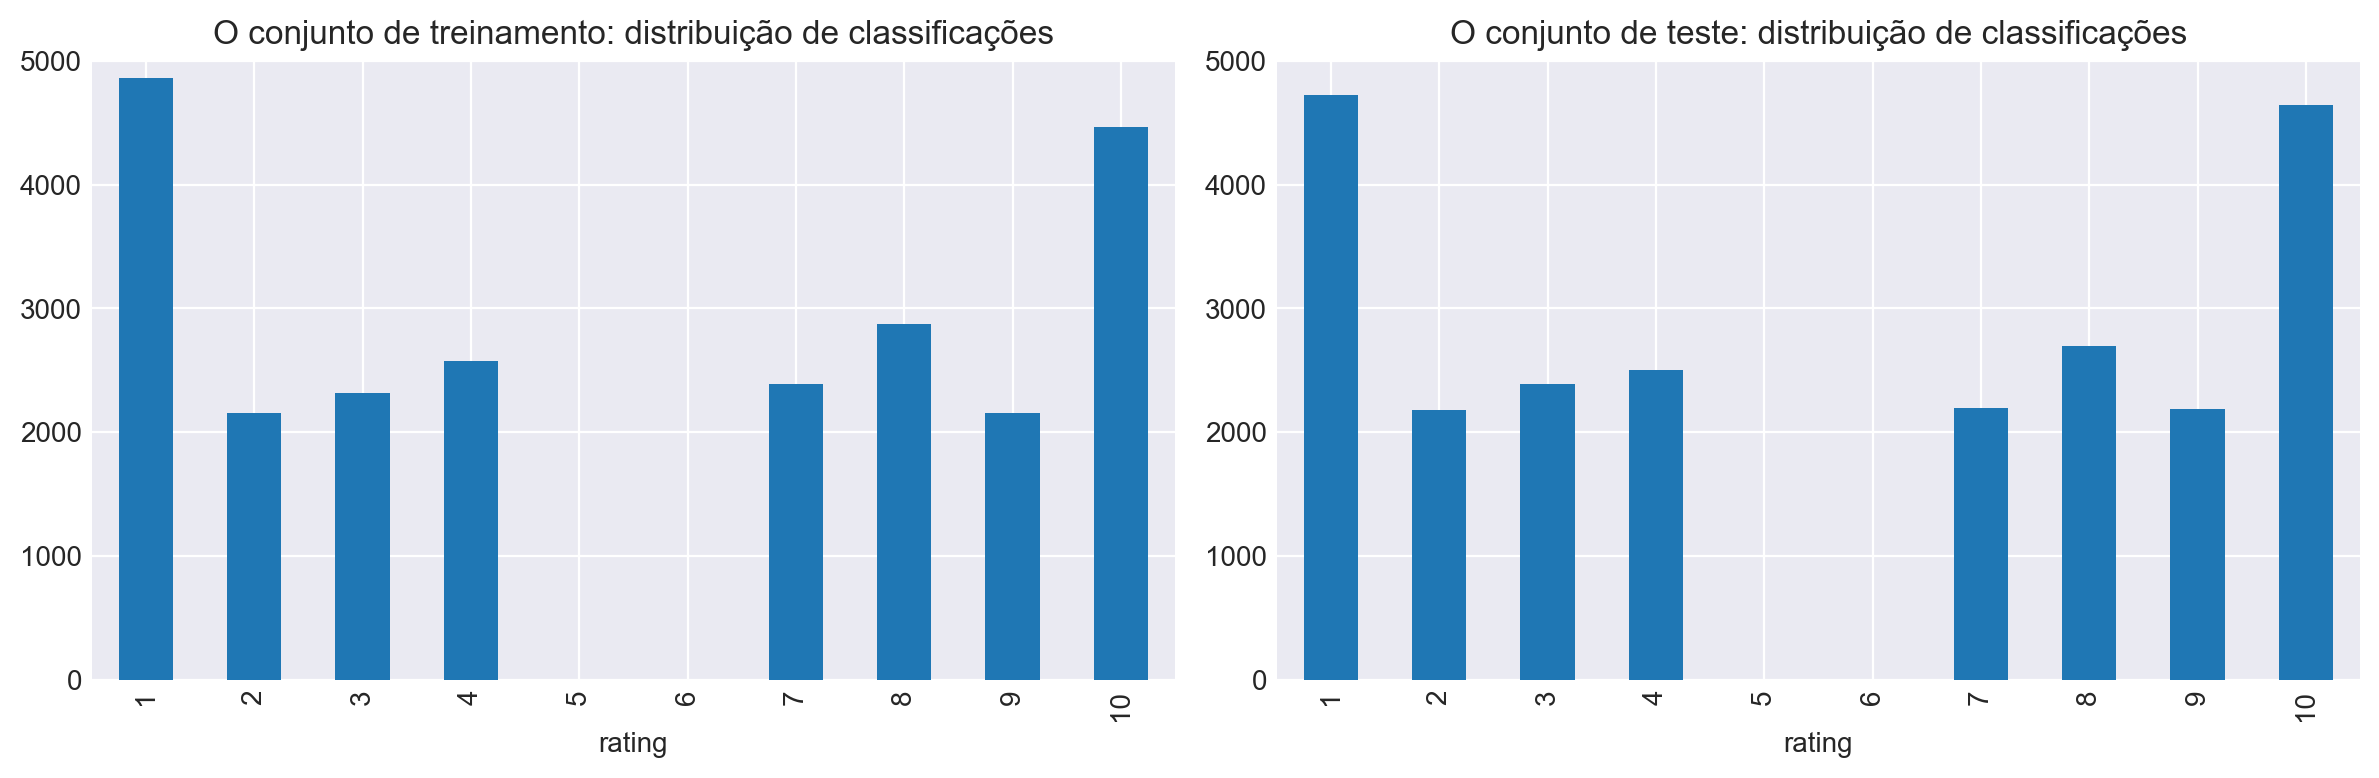

In [45]:
# análise de distribuição: quantidade de resenhas por classificação (rating)
# configuração dos gráficos
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]

# cotntagem de resenhas do conjunto de treinamento por classificação, preenchendo com zero onde não houver resenhas
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de treinamento: distribuição de classificações')

ax = axs[1]

# contagem de resenhas do conjunto de teste por classificação, preenchendo com zero onde não houver resenhas
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de teste: distribuição de classificações')

fig.tight_layout()

Distribuição de resenhas negativas e positivas ao longo dos anos para duas partes do conjunto de dados

C:\Users\galli\AppData\Local\Temp\ipykernel_19604\323660846.py:18: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
C:\Users\galli\AppData\Local\Temp\ipykernel_19604\323660846.py:19: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
C:\Users\galli\AppData\Local\Temp\ipykernel_19604\323660846.py:36: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
C:\Users\galli\AppData\Local\Temp\ipykernel_19604\323660846.py:37: UserWarning: 

Support for alter

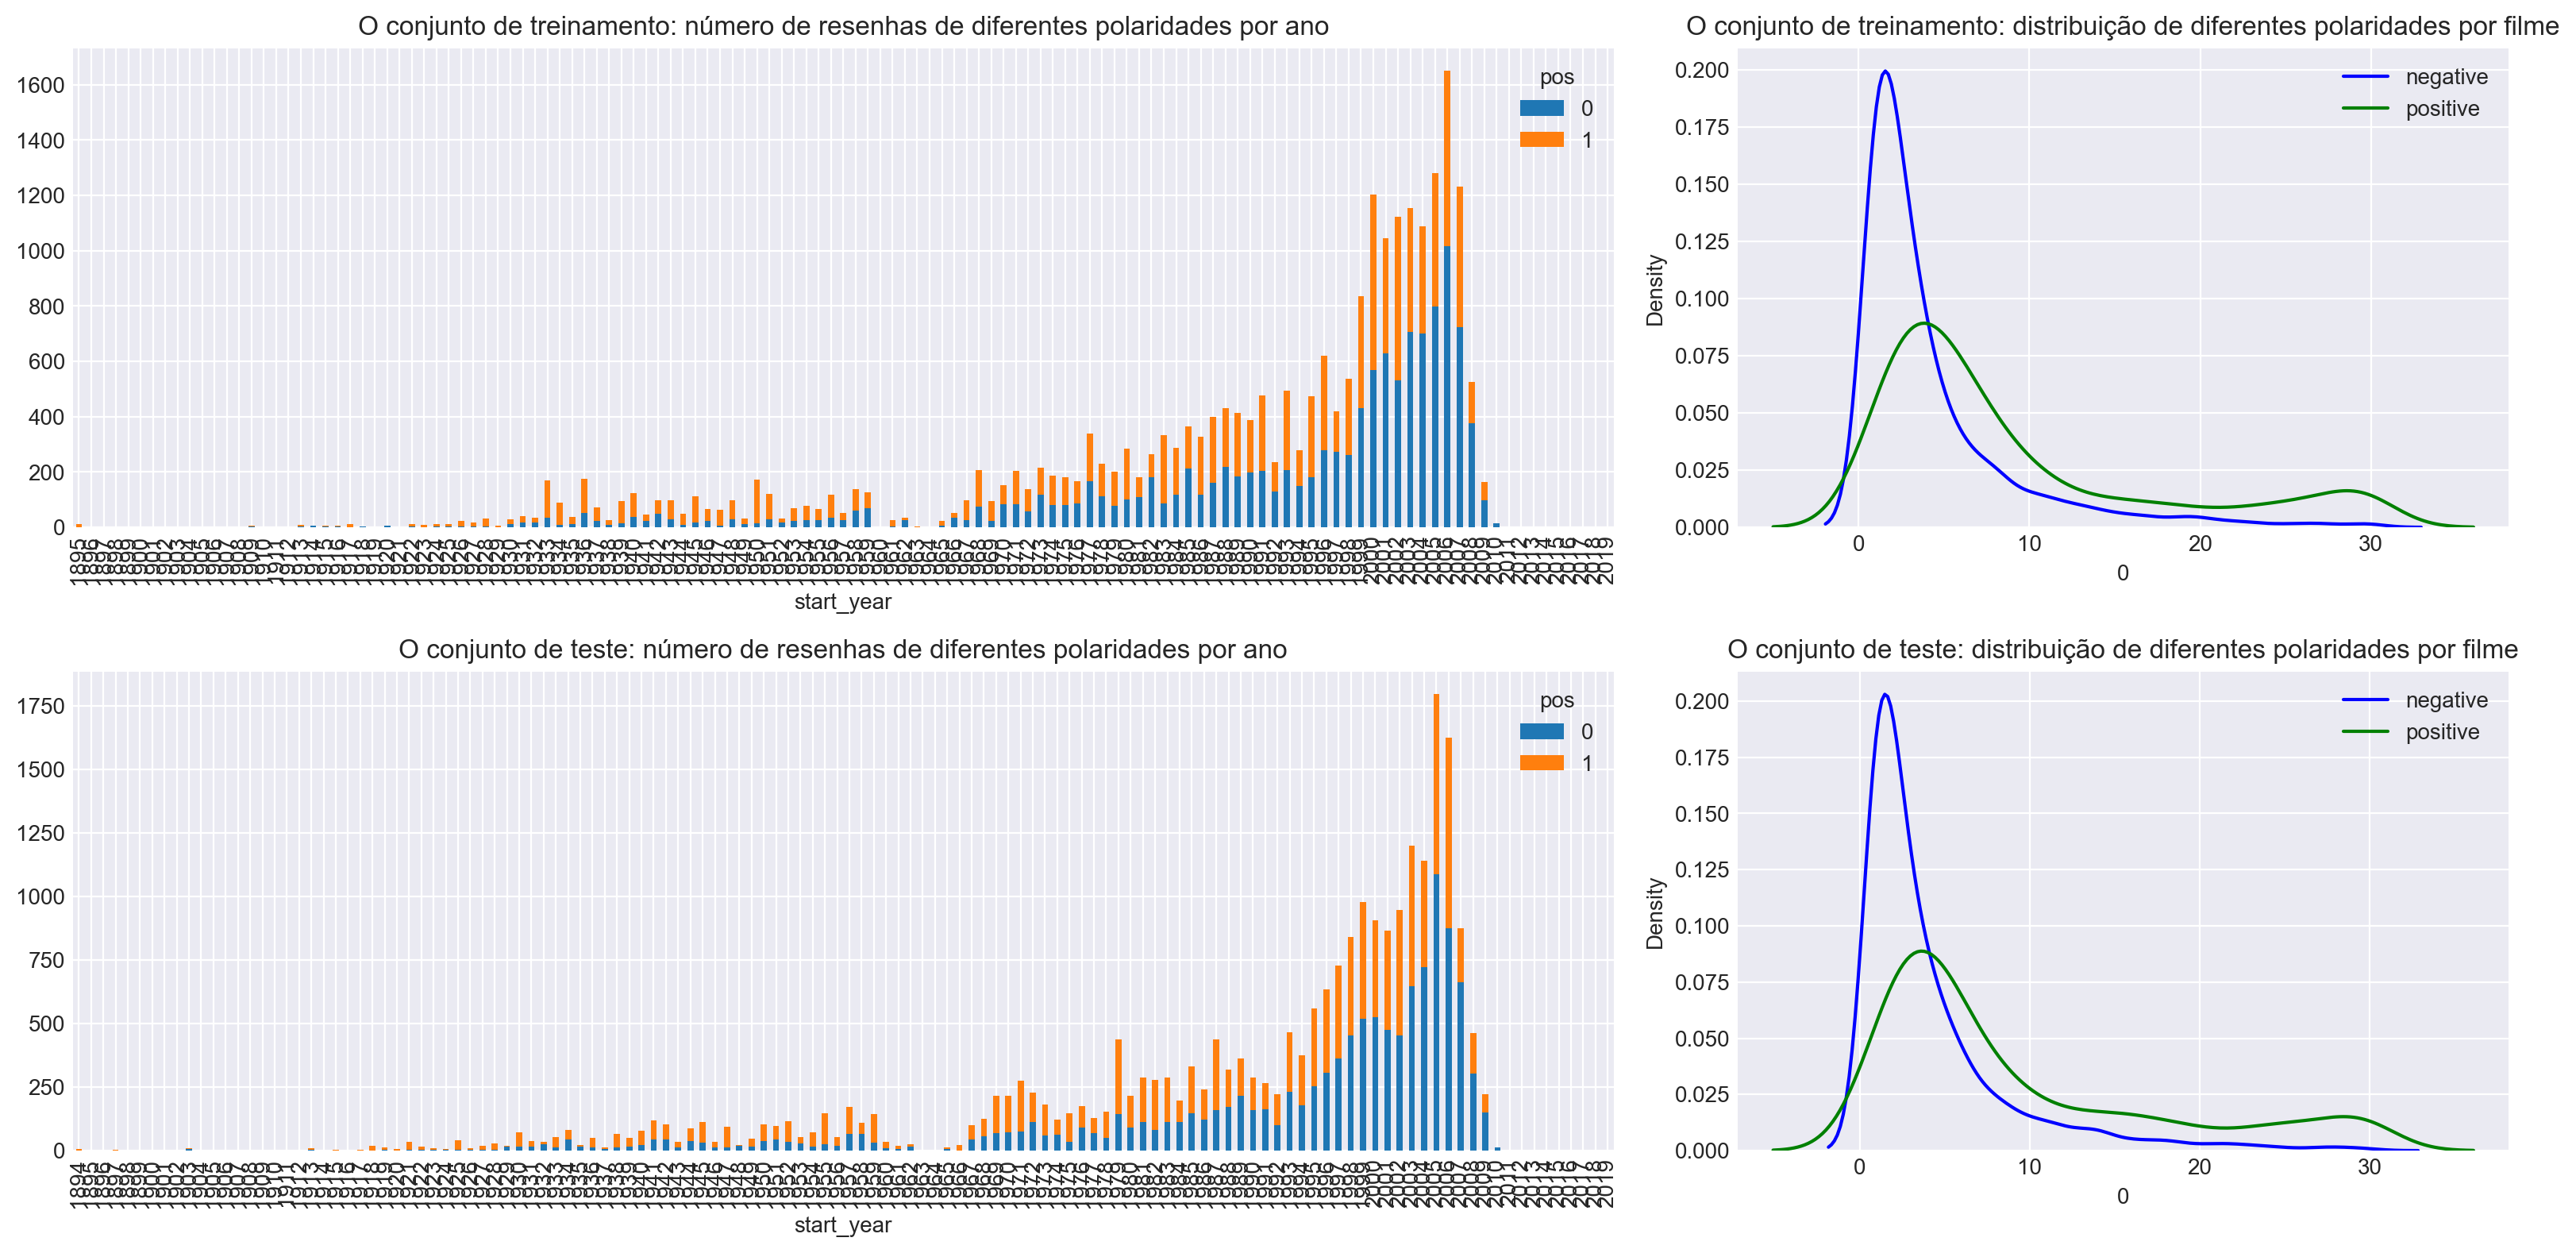

In [46]:
# análise de distribuição: quantidade de resenhas por polaridade (sentimento) ao longo dos anos
# configuração dos gráficos
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

# agrupamento dos dados de treinamento por ano e sentimento ('pos'), preenchendo anos sem resenhas com valor zero e ordenando por ano
dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de treinamento: número de resenhas de diferentes polaridades por ano')

ax = axs[0][1]

# agrupamento dos dados de treinamento por filme e sentimento ('pos'), preenchendo filmes sem resenhas com valor zero
dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('O conjunto de treinamento: distribuição de diferentes polaridades por filme')

ax = axs[1][0]

# agrupamento dos dados de teste por ano e sentimento ('pos'), preenchendo anos sem resenhas com valor zero e ordenando por ano
dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de teste: número de resenhas de diferentes polaridades por ano')

ax = axs[1][1]

# agrupamento dos dados de teste por filme e sentimento ('pos'), preenchendo filmes sem resenhas com valor zero
dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('O conjunto de teste: distribuição de diferentes polaridades por filme')

fig.tight_layout()

### Conclusões sobre os Gráficos: Etapa EAD

`Análise Temporal: número de filmes e resenhas por ano`
- Identificou-se o aumento de linear de registros a partir dos anos 1990, atingindo o pico entre 2003 e 2006. Risco de viés: tendência a performar melhor em filmes modernos, e o vocabulário das resenhas dos anos 2000 dominará o treinamento em relação a linguagem das resenhas dos filmes da décade de 1930.
- Observou-se lacuna temporal com pouca quantidade de filmes e resenhas no início da década de 60, que coincide com o período da segunda guerra mundial. A falta de exemplos neste período pode implicar em queda de acurácia. Há também ausência de filmes a partir do anos 2010. 
- Apesar de termos menor quantidade de filmes antigos, o engajamento médio (resenhas por filme) em certos períodos clássicos (como as décadas de 50 e 80) é comparável ou até superior aos anos 2000 em termos de densidade por título.

`Análise de Distribuição: quantidade de resenhas por filme`
- A análise de densidade mostra que a base de dados é composta em sua maioria por filmes com baixa contagem de resenhas, seguindo uma distribuição de cauda longa.
- Observou-se um limite máximo de 30 resenhas por título, característica garante que o modelo seja exposto a uma grande variedade de obras cinematográficas, evitando que o treinamento seja dominado por um pequeno grupo de filmes excessivamente comentados.

`Análise de Distribuição: quantidade de resenhas por classificação (rating)`
- As classificações estão idênticas entre o conjunto de treinamento e de teste, garantindo a integridade da validação cruzada.
- Não há classificações intermediárias (5 e 6), portanto, os dados do dataset foram filtrados para ter classificações polarizadas, eliminando ambiguidades (neutralidade) que poderiam impactar negativamente no F1-score.
- Os clientes tendem a classificação extrema (1 e 10), sugerindo que o vocabulário contido nestas resenhas conterá adjetivos intensos, favorecendo a captação das características (features) para o modelo.
- As demais classificações estão equilibradas, o que exigirá atenção para as resenhas que se utilizem de sarcasmo ou críticas sutis.

`Análise de Distribuição: quantidade de resenhas por polaridade (0 ou 1)`
- Em ambos os gráficos, os resultados para o conjunto de treinamento e de teste são idênticos, garantindo a consistência para a avaliação do modelo.
- Análise Temporal da Distribuição das Polaridades por ano: há balanceamento estável entre as resenhas positivas e negativas ao longo dos anos, impedindo viéses relacionado às épocas no treinamento.
- Análise de Ditribuição das polaridades por filme: as resenhas negativas mostram maior concentração em filmes com baixo volume de críticas (pico íngrime < 5). Já as resenhas positivas distribuem-se de forma mais suave, sugerindo que o engajamento positivo é mais distribuído entre diferentes volumes de resenhas por filme.

## Procedimento de Avaliação

Compondo uma rotina de avaliação que pode ser utilizada para todos os modelos deste projeto

In [47]:
# função para avaliação dos modelos

def evaluate_model(model, train_features, train_target, test_features, test_target, model_name):
    '''
    Avalia o desempenho de um modelo de machine learning.

    Parâmetros:
    - model: o modelo de machine learning a ser avaliado
    - train_features: as características do conjunto de dados de treinamento
    - train_target: os rótulos do conjunto de dados de treinamento
    - test_features: as características do conjunto de dados de teste
    - test_target: os rótulos do conjunto de dados de teste

    Retorna:
    - eval_stats: um dicionário contendo as estatísticas de avaliação para os conjuntos de dados de treinamento e teste
    '''

    # dicionário para armazenamento das estatísticas de avaliação
    eval_stats = {}
    
    # configuração dos gráficos para avaliação
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    # ciclo for para avaliação do modelo em ambos os conjuntos de dados (treinamento e teste)
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        # inicialização do dicionário para o tipo de conjunto de dados (treinamento ou teste)
        eval_stats[type] = {}
        # obtenção das previsões do modelo para os rótulos e as probabilidades de classe positiva
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1-score para diferentes limiares de decisão
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC para mapear a taxa de verdadeiros positivos (TPR) e taxa de falsos positivos (FPR) para diferentes limiares de decisão
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # Curva de precisão-revocação para diferentes limiares
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        # definição das cores para os gráficos de acordo com o tipo de conjunto (treinamento ou teste)
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'


        # configuração dos gráficos para a avaliação do modelo

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)

        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'Curva ROC')
        
        # Curva de precisão-revocação
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = f1_scores[max_f1_score_idx]
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)

    # criação de um dicionário com os dados do conjunto de teste para resumo executivo final
    resumo_modelo = {
        'Model': model_name,
        'Accuracy': df_eval_stats.loc['Accuracy', 'test'],
        'F1': df_eval_stats.loc['F1', 'test'],
        'APS': df_eval_stats.loc['APS', 'test'],
        'ROC AUC': df_eval_stats.loc['ROC AUC', 'test']
    }
    
    return resumo_modelo


## Normalização

Assumimos que todos os modelos abaixo aceitam textos em letras minúsculas e sem dígitos, sinais de pontuação, etc.

In [48]:
# padronização dos textos das resenhas e criação de uma nova coluna 'review_norm' com os textos normalizados

df_reviews['review_norm'] = (
    df_reviews['review']
    .str.lower()                               # converte strings para letras minúsculas
    .replace(r'[^a-zA-Z\s]', ' ', regex=True)  # substitui pontuação e dígitos por espaço
    .replace(r'\s+', ' ', regex=True)          # transforma múltiplos espaços em um só
    .str.strip()                               # remove espaços nas extremidades
)

## Treinar / Testar Conjunto

Felizmente, todo o conjunto de dados já está dividido em partes de treinamento/teste. A opção correspondente é 'ds_part'.

In [49]:
# filtro para selecionar os conjuntos de treinamento e teste, criando dataframes para cada um
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

# definição das targets para os conjuntos de treinamento e teste
train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print('=' * 40)
print(f"📐 Dimensões dos Dataframes")
print('=' * 40)
print(df_reviews_train.shape)
print(df_reviews_test.shape)

print('=' * 40)
print(f"📊 Proporção de Resenhas Positivas")
print('=' * 40)
print(f"Conjunto de Treino: {train_target.mean().round(2):.2%}")
print(f"Conjunto de Teste: {test_target.mean().round(2):.2%}")

📐 Dimensões dos Dataframes
(23796, 19)
(23533, 19)
📊 Proporção de Resenhas Positivas
Conjunto de Treino: 50.00%
Conjunto de Teste: 50.00%


## Trabalhando com modelos

### Modelo 0 - Constante

📈 Resultados: Modelo 0 (Constante/Dummy)
          train  test
Accuracy   0.50  0.50
F1         0.67  0.67
APS        0.50  0.50
ROC AUC    0.50  0.50
{'Model': 'Constante', 'Accuracy': np.float64(0.5), 'F1': np.float64(0.67), 'APS': np.float64(0.5), 'ROC AUC': np.float64(0.5)}


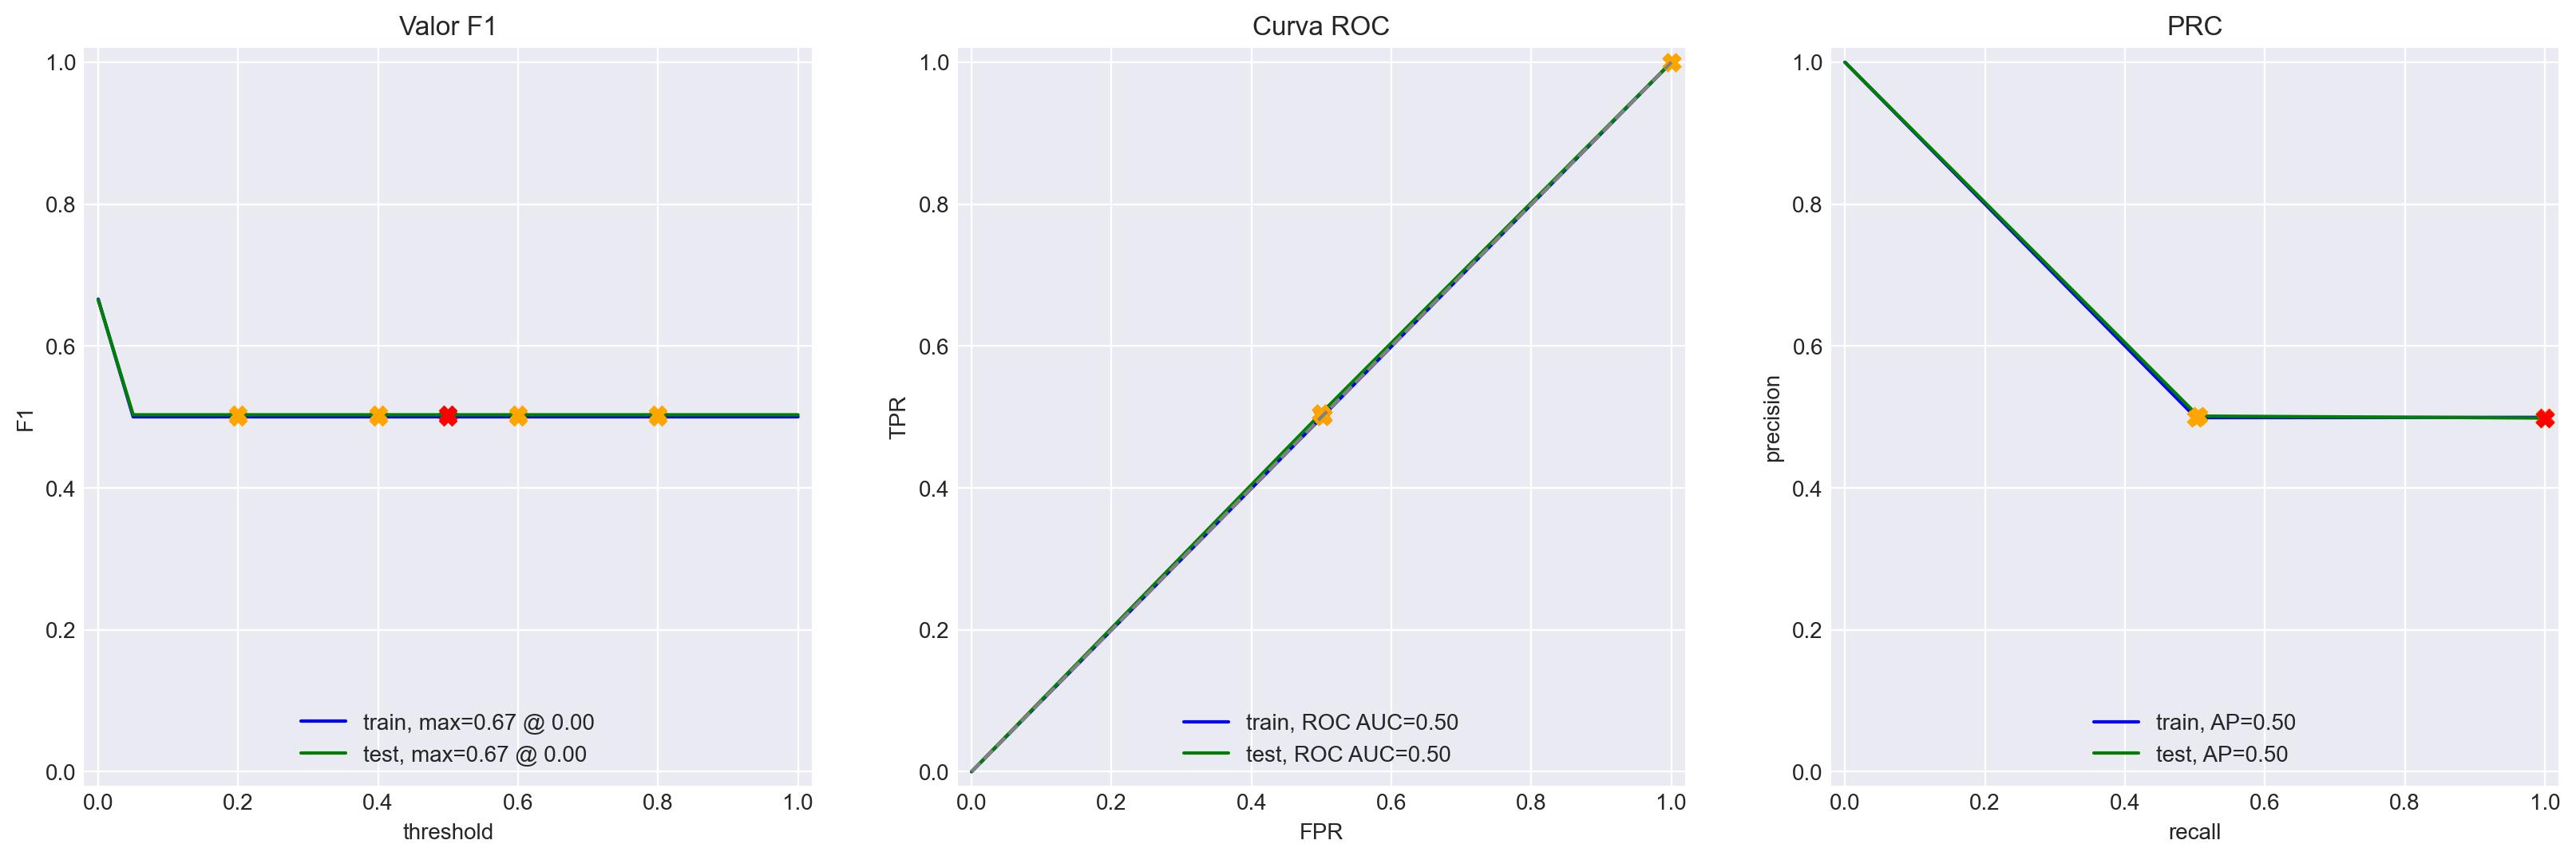

In [50]:
# instanciar o modelo Dummy
# 'stratified' garante que o "chute" respeite os ~50% de cada classe que você calculou
model_0 = DummyClassifier(strategy='stratified', random_state=42)

# definição das features para os conjuntos de treinamento e teste
train_features = df_reviews_train['review_norm']
test_features = df_reviews_test['review_norm']

# treinar o modelo
model_0.fit(train_features, train_target)

# chamar a função de avaliação para o modelo Dummy
print('=' * 50)
print(f"📈 Resultados: Modelo 0 (Constante/Dummy)")
print('=' * 50)

res_dummy =evaluate_model(model_0, train_features, train_target, test_features, test_target, model_name='Constante')

# criação de uma lista para armazenar os resumos dos modelos para apresentação final
resumo_modelos = []
# armezenamento do resumo do modelo Dummy na lista de resumos
resumo_modelos.append(res_dummy)

print(res_dummy)

`Análise da Performance do Modelo 0: Constante / Dummy (baseline)`
- As métricas de acurácia, APS e ROC AUC com resultado de 0.50, confirmando que o modelo trabalha "ao acaso", sem capacidade de distinção de resenhas positivas e negativas.
- F1-score o resultado foi 0.67 no limiar 0.0, este resultado não representa melhoria real da qualidade de classificação, visto ser um resultado devido a classificação de todas as instâncias como positivas no dataset balanceado.
- **Não atende ao Requesito:** F1-score 0.67 não atende ao requesito do projeto (F1-score > 0.85).


### Modelo 1 - NLTK, TF-IDF e Regressão Logística

TF-IDF

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\galli\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


📈 Resultados: Modelo 1 (TF-IDF +Regressão Logística)
          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95
{'Model': 'Logistic Regression', 'Accuracy': np.float64(0.88), 'F1': np.float64(0.88), 'APS': np.float64(0.95), 'ROC AUC': np.float64(0.95)}


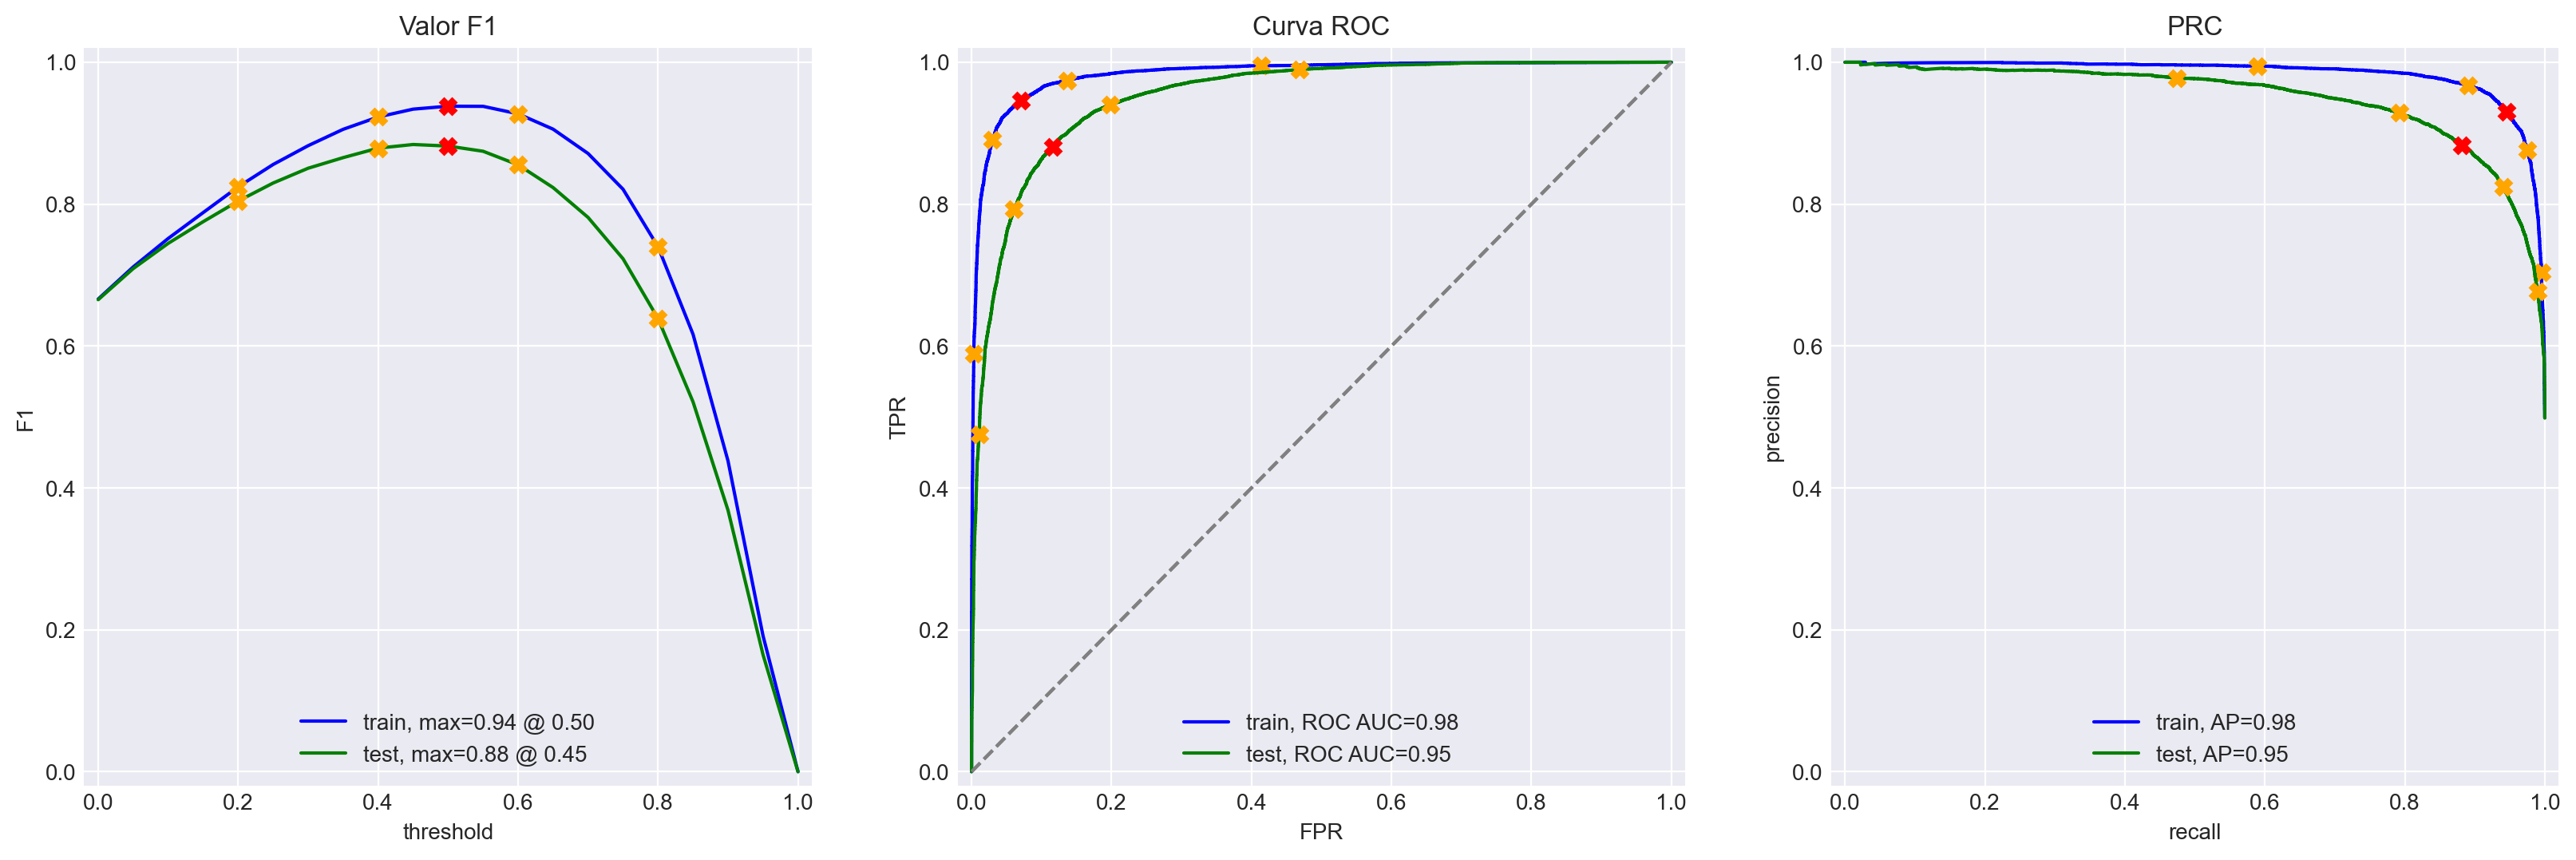

In [51]:
# instanciar o modelo TF-IDF
# baixando as stop words do NLTK para o idioma inglês
nltk.download('stopwords')
stop_words = list(set(nltk.corpus.stopwords.words('english')))

# instanciar o vetorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(stop_words=stop_words)

# transformar o texto em números (features)
train_features_1 = tfidf_vectorizer.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf_vectorizer.transform(df_reviews_test['review_norm'])

# instanciar o modelo de regressão logística
model_1 = LogisticRegression(random_state=42)

# treinar o modelo
model_1.fit(train_features_1, train_target)

# chamar a função de avaliação para o modelo de regressão logística
print('=' * 55)
print(f"📈 Resultados: Modelo 1 (TF-IDF +Regressão Logística)")
print('=' * 55)

res_logistic = evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target, model_name='Logistic Regression')

# armezenamento do resumo do modelo Dummy na lista de resumos
resumo_modelos.append(res_logistic)

print(res_logistic)

`Análise de Performance do Modelo 1: Regressão Logística`
- Optou-se em utilizar **Regressão Logística**, pois é mais adequado para problemas de classificação binária de sentimentos, pois retorna a probabilidade de pertercer ou não a determinada categoria.
- **Superação do Baseline:** o modelo demonstrou um aprendizado real, saindo de um ROC AUC de 0.50 (acaso) para 0.95, evidenciando que a vetorização TF-IDF com Stop Words foi eficaz em extrair semântica das resenhas.
- **Overfitting:** embora exista um leve distanciamento entre as métricas de treino (0.94) e teste (0.88), o modelo mantém uma alta capacidade de generalização. O valor de APS (0.95) confirma que a precisão média é consistente em diferentes níveis de recall.
- **Atendimento ao Requesito:** atingiu um F1-score de 0.88 no conjunto de teste, superando a meta estabelecida de 0.85.

In [54]:
# Criando o dataframe consolidado
df_comparativo_final = pd.DataFrame(resumo_modelos)

# Formatando para a apresentação executiva
display(df_comparativo_final.sort_values(by='F1', ascending=False))

,Model,Accuracy,F1,APS,ROC AUC
1,Logistic Regression,0.88,0.88,0.95,0.95
0,Constante,0.50,0.67,0.50,0.50


### Modelo 3 - spaCy, TF-IDF e Regressão Linear

In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [ ]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

### Modelo 4 - SpaCy, TF-IDF e LGBMClassifier

In [ ]:
from lightgbm import LGBMClassifier

###  Modelo 9 - BERT

In [ ]:
import torch
import transformers

ModuleNotFoundError: No module named 'torch'

In [ ]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

In [ ]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
    ids_list = []
    attention_mask_list = []

    # texto para IDs de tokens preenchidos com suas máscaras de atenção
    
    # <coloque seu código aqui para criar ids_list e attention_mask_list>
    
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    if not disable_progress_bar:
        print(f'Usando o dispositivo {device}.')
    
    # recebendo incorporações em lotes

    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
            
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        # <coloque seu código aqui para criar attention_mask_batch
            
        with torch.no_grad():            
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
        
    return np.concatenate(embeddings)

In [ ]:
# Atenção! A execução do BERT para milhares de textos pode levar muito tempo na CPU, pelo menos várias horas
train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cuda')

In [ ]:
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

In [ ]:
# se você tiver as incorporações, é aconselhável salvá-las para tê-las prontas se 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# e carregar...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

## Minhas Resenhas

In [ ]:
# sinta-se à vontade para remover completamente essas resenhas e experimentar seus modelos nas suas próprias resenhas, as abaixo são apenas exemplos

my_reviews = pd.DataFrame([
    'Eu simplesmente não gostei, não é meu tipo de filme.',
    'Bem, eu fiquei entediado e dormi no meio do filme.',
    'Eu fiquei realmente fascinado com o filme',    
    'Os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do filme. Que roubo de dinheiro sem vergonha.',
    'Eu não esperava que a nova versão fosse tão boa! Os escritores realmente se importaram com o material original',
    'O filme tem seus prós e contras, mas eu sinto que em geral é um filme decente. Eu posso me imaginar indo assistir novamente.',
    'Que tentativa podre de comédia. Nem uma única piada cai, todo mundo age de forma irritante e barulhenta, nem crianças não vão gostar disso!',
    'Lançar na Netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episódio após episódio, deste emocionante e inteligente novo drama.'
], columns=['review'])

my_reviews['review_norm'] = # <coloque aqui a mesma lógica de normalização do conjunto de dados principal>

my_reviews

### Modelo 2

In [ ]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_2.predict_proba(tfidf_vectorizer_2.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

### Modelo 3

In [ ]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

### Modelo 4

In [ ]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_vectorizer_3
my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

### Modelo 9

In [ ]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

## Conclusões

# Checklist

- [x]  O caderno foi aberto
- [ ]  Os dados de texto são carregados e pré-processados para vetorização
- [ ]  Os dados de texto são transformados em vetores
- [ ]  Os modelos são treinados e testados
- [ ]  O limiar da métrica foi atingido
- [ ]  Todas as células de código estão organizadas na ordem de sua execução
- [ ]  Todas as células de código podem ser executadas sem erros
- [ ]  Há conclusões 